#  Prevendo Emissões de CO₂ com Regressão Linear Múltipla

**Projeto de Machine Learning — Regressão Supervisionada**

##  Objetivo
Desenvolver um modelo capaz de prever as emissões de CO₂ (`CO2EMISSIONS`) utilizando múltiplas características dos veículos.

Anotar minhas observaçõos para que se torne um material de estudo.

### Variáveis utilizadas
- `ENGINESIZE`
- `FUELCONSUMPTION_COMB_MPG`

### Pergunta de análise
> A combinação de tamanho do motor e eficiência de combustível melhora a capacidade de prever as emissões de CO₂?

##  Tecnologias e conceitos

- Python
- Pandas / NumPy
- Matplotlib
- Scikit-learn
- Regressão Linear Múltipla
- Padronização (`StandardScaler`)
- Train/Test Split
- MAE, RMSE e R²
- Correlação e análise de multicolinearidade

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Carregamento dos dados

In [2]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

df = pd.read_csv(url)

print(f"Dimensões: {df.shape}")
df.head()

Dimensões: (1067, 13)


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [3]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
MODELYEAR,1067.0,2014.00,0.00,2014.0,2014.00,2014.0,2014.00,2014.0
ENGINESIZE,1067.0,3.35,1.42,1.0,2.00,3.4,4.30,8.4
CYLINDERS,1067.0,5.79,1.80,3.0,4.00,6.0,8.00,12.0
FUELCONSUMPTION_CITY,1067.0,13.30,4.10,4.6,10.25,12.6,15.55,30.2
FUELCONSUMPTION_HWY,1067.0,9.47,2.79,4.9,7.50,8.8,10.85,20.5
FUELCONSUMPTION_COMB,1067.0,11.58,3.49,4.7,9.00,10.9,13.35,25.8
FUELCONSUMPTION_COMB_MPG,1067.0,26.44,7.47,11.0,21.00,26.0,31.00,60.0
CO2EMISSIONS,1067.0,256.23,63.37,108.0,207.00,251.0,294.00,488.0


## 2. Seleção de variáveis

O dataset possui variáveis categóricas e numéricas. Para este projeto, vamos trabalhar com duas variáveis numéricas selecionadas pela relação observada com o target.

A escolha também considera a redundância entre algumas variáveis de consumo de combustível.

In [4]:
features = ["ENGINESIZE", "FUELCONSUMPTION_COMB_MPG"]
target = "CO2EMISSIONS"

model_df = df[features + [target]].copy()

model_df.describe().round(2)

,ENGINESIZE,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.00,1067.00,1067.00
mean,3.35,26.44,256.23
std,1.42,7.47,63.37
min,1.00,11.00,108.00
25%,2.00,21.00,207.00
50%,3.40,26.00,251.00
75%,4.30,31.00,294.00
max,8.40,60.00,488.00


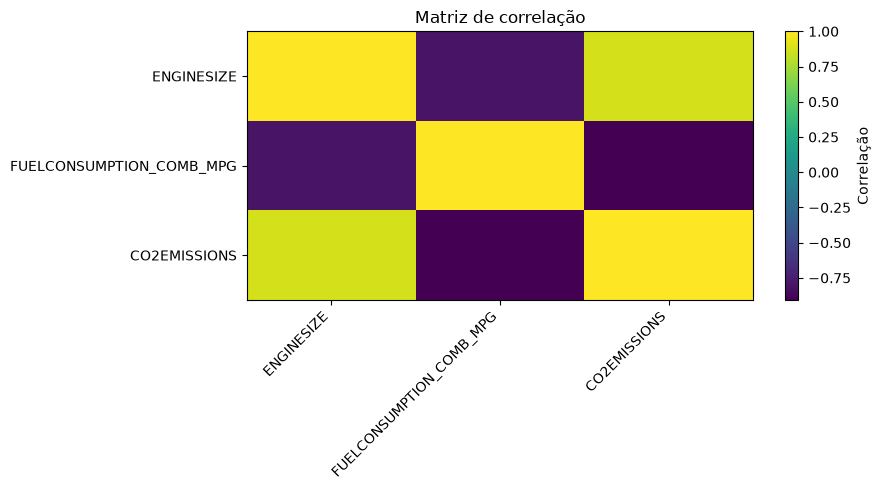

,ENGINESIZE,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
ENGINESIZE,1.000,-0.809,0.874
FUELCONSUMPTION_COMB_MPG,-0.809,1.000,-0.906
CO2EMISSIONS,0.874,-0.906,1.000


In [5]:
plt.figure(figsize=(9, 5))
corr = model_df.corr(numeric_only=True)
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar(label="Correlação")
plt.title("Matriz de correlação")
plt.tight_layout()
plt.show()

corr.round(3)

### Observação

As variáveis selecionadas apresentam relação relevante com `CO2EMISSIONS`. Ao mesmo tempo, correlações elevadas entre variáveis preditoras podem indicar redundância e dificultar a interpretação dos coeficientes.

## 3. Separação entre treino e teste

**Importante:** o split acontece **antes** da padronização. Dessa forma, o scaler é ajustado apenas com os dados de treinamento, evitando vazamento de informação do conjunto de teste.

A transformação será encapsulada em um `Pipeline`.

In [6]:
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (853, 2)
Teste: (214, 2)


## 4. Pipeline de Machine Learning

O pipeline executa duas etapas:

1. **StandardScaler:** coloca as features em uma escala comparável.
2. **LinearRegression:** aprende a relação entre as features e as emissões de CO₂.

In [7]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['ENGINESIZE','FUELCONSUMPTION_COMB_MPG']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [8]:
regressor = pipeline.named_steps["regressor"]

coefficients = pd.Series(
    regressor.coef_,
    index=features,
    name="Coeficiente"
)

coefficients.round(3)

ENGINESIZE                  25.249
FUELCONSUMPTION_COMB_MPG   -36.606
Name: Coeficiente, dtype: float64

## 5. Avaliação do modelo

In [9]:
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R²"],
    "Valor": [mae, rmse, r2]
})

metrics.round(3)

,Métrica,Valor
0,MAE,14.286
1,RMSE,21.590
2,R²,0.887


## 6. Real × previsto

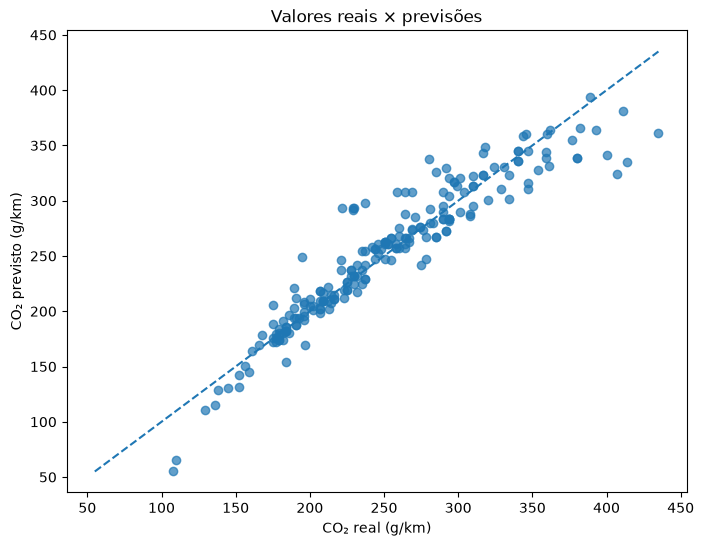

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.xlabel("CO₂ real (g/km)")
plt.ylabel("CO₂ previsto (g/km)")
plt.title("Valores reais × previsões")
plt.show()

## 7. Análise dos resíduos

Resíduos são a diferença entre o valor real e a previsão. Padrões nos resíduos podem indicar que a relação não é bem representada por uma função linear.

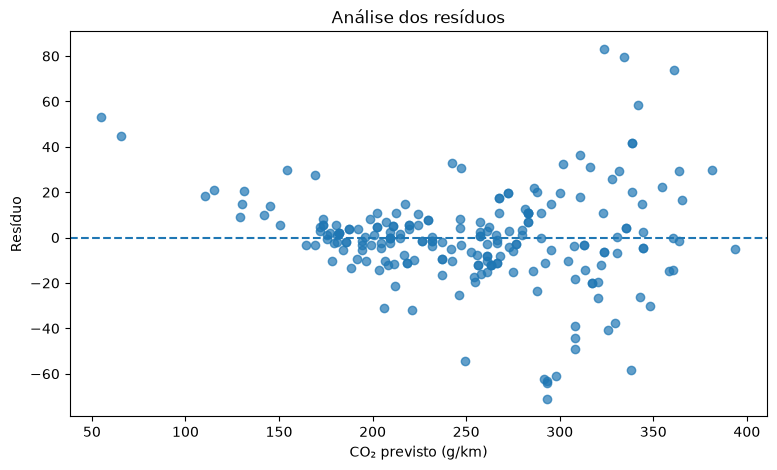

In [11]:
residuals = y_test - y_pred

plt.figure(figsize=(9, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("CO₂ previsto (g/km)")
plt.ylabel("Resíduo")
plt.title("Análise dos resíduos")
plt.show()

## 8. Conclusões

### Principais aprendizados
- Regressão Linear Múltipla permite combinar várias features para prever um target contínuo.
- A padronização pode facilitar o treinamento e a comparação dos coeficientes.
- O `Pipeline` ajuda a evitar inconsistências no pré-processamento.
- A análise de resíduos ajuda a identificar limitações do modelo linear.

### Limitações
O dataset apresenta relações que podem ser não lineares. Por isso, um modelo linear pode não capturar completamente o comportamento das emissões.

### Próximos experimentos
- Regressão polinomial.
- Random Forest Regressor.
- Gradient Boosting.
- Comparação sistemática de métricas.
- Validação cruzada e ajuste de hiperparâmetros.

##  Referências

- Dataset: Open Government Canada — Fuel Consumption Ratings.
- Biblioteca: Scikit-learn.

